### 특성(Feature) 공학과 규제(Regularization: 정형화, 일반화, 규제)

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../Data/fish.csv")
df.head()

,length,height,width
0,8.4,2.11,1.41
1,13.7,3.53,2.00
2,15.0,3.82,2.43
3,16.2,4.59,2.63
4,17.4,4.59,2.94


In [3]:
df.shape

(56, 3)

In [4]:
df.describe()

,length,height,width
count,56.000000,56.000000,56.000000
mean,27.892857,7.862143,4.745536
std,9.021668,2.878343,1.775006
min,8.400000,2.110000,1.410000
25%,21.825000,5.690000,3.520000
50%,25.300000,6.920000,4.155000
75%,36.625000,10.850000,6.450000
max,44.000000,12.800000,8.140000


In [5]:
import numpy as np

In [9]:
fish_full = df.to_numpy()
fish_full[:6]

array([[ 8.4 ,  2.11,  1.41],
       [13.7 ,  3.53,  2.  ],
       [15.  ,  3.82,  2.43],
       [16.2 ,  4.59,  2.63],
       [17.4 ,  4.59,  2.94],
       [18.  ,  5.22,  3.32]])

In [10]:
df = pd.read_csv("../Data/fish_weight.csv")
df.head()

,weight
0,5.9
1,32.0
2,40.0
3,51.5
4,70.0


In [11]:
fish_weight = df.to_numpy()
fish_weight[:6]

array([[  5.9],
       [ 32. ],
       [ 40. ],
       [ 51.5],
       [ 70. ],
       [100. ]])

### Train과 Test

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
train_input, test_input, train_target, test_target = \
                        train_test_split(
                                fish_full,
                                fish_weight,
                                random_state=42
                        )

In [14]:
print(train_input.shape)
print(test_input.shape)
print(train_target.shape)
print(test_target.shape)

(42, 3)
(14, 3)
(42, 1)
(14, 1)


### scikit learn으로 다중회귀 분석하기

###### 다중 회귀 모델 

In [15]:
from sklearn.linear_model import LinearRegression

In [16]:
lr = LinearRegression()
lr.fit(train_input, train_target)
print("Train :", lr.score(train_input, train_target))
print("Test :", lr.score(test_input, test_target))

Train : 0.9559326821885706
Test : 0.8796419177546366


----
#### 연습하기

In [17]:
# 특성 생성
from sklearn.preprocessing import PolynomialFeatures

In [18]:
poly = PolynomialFeatures()
poly.fit([[2,3]])
print(poly.transform([[2,3]]))

[[1. 2. 3. 4. 6. 9.]]


1: 절편, 2:x, 3:y, 4:x^2, 6:x*y, 9:y^2    

In [19]:
poly = PolynomialFeatures(include_bias=False)
poly.fit([[2,3]])
print(poly.transform([[2,3]]))

[[2. 3. 4. 6. 9.]]


---
#### 다항 특성 만들기


In [20]:
# train_input으로 다항 특성 만들기
poly = PolynomialFeatures(include_bias=False) # degree = 2
poly.fit(train_input)
train_poly = poly.transform(train_input)
train_poly.shape

(42, 9)

In [21]:
train_poly[:6]

array([[  19.6   ,    5.14  ,    3.04  ,  384.16  ,  100.744 ,   59.584 ,
          26.4196,   15.6256,    9.2416],
       [  22.    ,    5.88  ,    3.52  ,  484.    ,  129.36  ,   77.44  ,
          34.5744,   20.6976,   12.3904],
       [  18.7   ,    5.2   ,    3.12  ,  349.69  ,   97.24  ,   58.344 ,
          27.04  ,   16.224 ,    9.7344],
       [  17.4   ,    4.59  ,    2.94  ,  302.76  ,   79.866 ,   51.156 ,
          21.0681,   13.4946,    8.6436],
       [  36.    ,   10.61  ,    6.74  , 1296.    ,  381.96  ,  242.64  ,
         112.5721,   71.5114,   45.4276],
       [  25.    ,    6.44  ,    3.68  ,  625.    ,  161.    ,   92.    ,
          41.4736,   23.6992,   13.5424]])

In [22]:
# 컬럼 정보 확인
poly.get_feature_names_out()

array(['x0', 'x1', 'x2', 'x0^2', 'x0 x1', 'x0 x2', 'x1^2', 'x1 x2',
       'x2^2'], dtype=object)

In [24]:
# test_input도 다항 특성 만들기
test_poly = poly.transform(test_input)

In [25]:
lr = LinearRegression()
lr.fit(train_poly, train_target)
print("Train :", lr.score(train_poly, train_target))
print("Test :", lr.score(test_poly, test_target))

Train : 0.9903183436982124
Test : 0.9714559911594203


---
#### 더 많은 특성 만들기

In [26]:
# degree = 5 
poly = PolynomialFeatures(include_bias=False, degree=5) # Default : degree = 2
poly.fit(train_input)
train_poly = poly.transform(train_input)
train_poly.shape

(42, 55)

In [29]:
test_poly = poly.transform(test_input)

In [30]:
# 컬럼 정보
poly.get_feature_names_out()

array(['x0', 'x1', 'x2', 'x0^2', 'x0 x1', 'x0 x2', 'x1^2', 'x1 x2',
       'x2^2', 'x0^3', 'x0^2 x1', 'x0^2 x2', 'x0 x1^2', 'x0 x1 x2',
       'x0 x2^2', 'x1^3', 'x1^2 x2', 'x1 x2^2', 'x2^3', 'x0^4', 'x0^3 x1',
       'x0^3 x2', 'x0^2 x1^2', 'x0^2 x1 x2', 'x0^2 x2^2', 'x0 x1^3',
       'x0 x1^2 x2', 'x0 x1 x2^2', 'x0 x2^3', 'x1^4', 'x1^3 x2',
       'x1^2 x2^2', 'x1 x2^3', 'x2^4', 'x0^5', 'x0^4 x1', 'x0^4 x2',
       'x0^3 x1^2', 'x0^3 x1 x2', 'x0^3 x2^2', 'x0^2 x1^3',
       'x0^2 x1^2 x2', 'x0^2 x1 x2^2', 'x0^2 x2^3', 'x0 x1^4',
       'x0 x1^3 x2', 'x0 x1^2 x2^2', 'x0 x1 x2^3', 'x0 x2^4', 'x1^5',
       'x1^4 x2', 'x1^3 x2^2', 'x1^2 x2^3', 'x1 x2^4', 'x2^5'],
      dtype=object)

In [31]:
lr = LinearRegression()
lr.fit(train_poly, train_target)
print("Train :", lr.score(train_poly, train_target))
print("Test :", lr.score(test_poly, test_target))

Train : 0.999999999997515
Test : -144.40196592191958


> train의 경우는 거의 완벽했지만 test는 엉망이다.    
과대적합이 발생 하였다.    
이런 경우 사용하는 것이 규제 이다.   

### 규제
: 모델이 과적합되게 학습하지 않고 일반성을 가질수 있도록 규제(정규화) 하는 것.

In [32]:
# 규제 전에 표준화
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(train_poly)

train_scaled = ss.transform(train_poly)
test_scaled = ss.transform(test_poly)

#### Ridge(L2규제) 회귀
: 가중치의 제곱으로 규제하는 방법 

In [33]:
from sklearn.linear_model import Ridge

In [39]:
ridge = Ridge(alpha=1) # defalut : alpha = 1
ridge.fit(train_scaled, train_target)
print("Train Score:", ridge.score(train_scaled, train_target))
print("Test Score :", ridge.score(test_scaled, test_target))

Train Score: 0.9896101671037343
Test Score : 0.9790693977615393


##### 적절한 규제 강도(Hyper parameter) 찾기

In [40]:
train_score = []
test_score = []
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100, 1000] # 임의로 정한다. 

for alpha in alpha_list:
    # 릿지 모델
    ridge = Ridge(alpha=alpha)
    # 릿지 훈련
    ridge.fit(train_scaled, train_target)
    # 훈련점수와 테스트 점수 저장
    train_score.append(ridge.score(train_scaled, train_target))
    test_score.append(ridge.score(test_scaled, test_target))

In [43]:
# 시각화 하기
import matplotlib.pyplot as plt

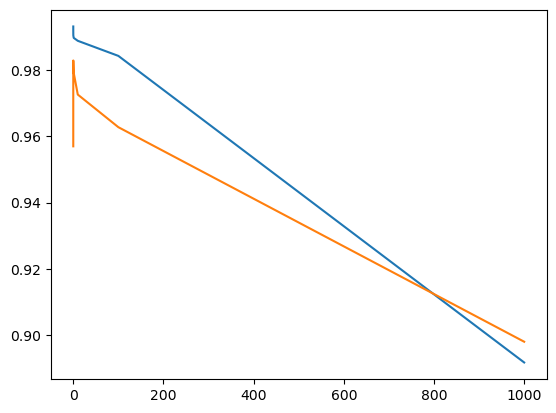

In [44]:
plt.plot(alpha_list, train_score)
plt.plot(alpha_list, test_score)
plt.show()

> x축의 데이터 범위가 너무커서 소수인 경우에는 확인할 수 없음.     
log를 사용해 데이터의 범위 축소  

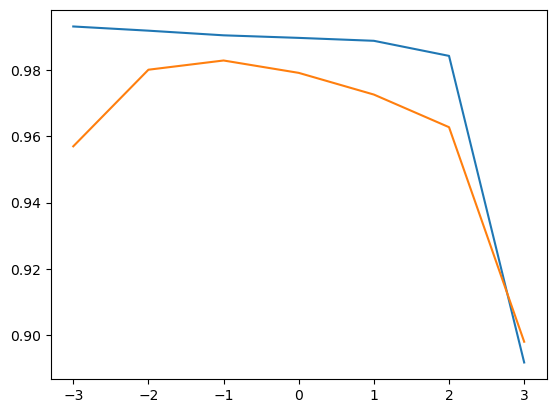

In [45]:
plt.plot(np.log10(alpha_list), train_score)
plt.plot(np.log10(alpha_list), test_score)
plt.show()

> alpha가 -1인 경우 train과 test의 간격이 가깝다(Goldilocks)   
-1은 alpha list에서 0.1 이다.   

In [46]:
# 최적값 확인
ridge = Ridge(alpha=0.1) # defalut : alpha = 1
ridge.fit(train_scaled, train_target)
print("Train Score:", ridge.score(train_scaled, train_target))
print("Test Score :", ridge.score(test_scaled, test_target))

Train Score: 0.9903815817570366
Test Score : 0.9827976465386806


---
### Lasso(L1규제) 회귀
: Lasso 규제는 가중치의 절대값으로 규제하는 방법

In [47]:
from sklearn.linear_model import Lasso

In [48]:
lasso = Lasso()
lasso.fit(train_scaled, train_target)
print("Train score :", lasso.score(train_scaled, train_target))
print("Test Score  :", lasso.score(test_scaled, test_target))

Train score : 0.989789897208096
Test Score  : 0.9800593698421886


In [49]:
# 최적값 찾기
train_score = []
test_score = []
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100, 1000] # 임의로 정한다. 

for alpha in alpha_list:
    lasso = Lasso(alpha=alpha)
    lasso.fit(train_scaled, train_target)
    # 훈련점수와 테스트 점수 저장
    train_score.append(lasso.score(train_scaled, train_target))
    test_score.append(lasso.score(test_scaled, test_target))

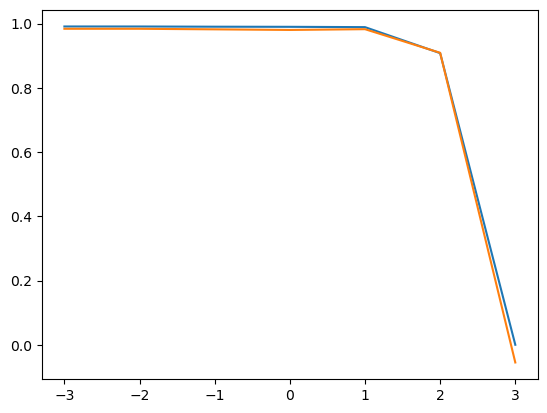

In [50]:
plt.plot(np.log10(alpha_list), train_score)
plt.plot(np.log10(alpha_list), test_score)
plt.show()

In [51]:
lasso = Lasso(alpha=10)
lasso.fit(train_scaled, train_target)
print("Train score :", lasso.score(train_scaled, train_target))
print("Test Score  :", lasso.score(test_scaled, test_target))

Train score : 0.9888067471131867
Test Score  : 0.9824470598706695


In [52]:
lasso.coef_

array([ 0.        ,  0.        ,  0.        , 12.14852453, 55.44856399,
       42.23100799,  0.        ,  0.        , 13.70596191,  0.        ,
       43.2185952 ,  5.7033775 , 47.46254536,  7.42309425, 11.85823365,
        0.        ,  0.        , 13.53038193, 21.22111356,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
       18.66993032,  0.        ,  0.        ,  0.        , 15.81041778,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        , 18.14672268,
        0.        ,  0.        ,  0.        ,  0.        , 15.51272953,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ])

In [53]:
np.sum(lasso.coef_ == 0)

40

In [54]:
ridge.coef_

array([[ 27.61933479,  -1.64022156, -19.73256036,  30.0306195 ,
         16.99800255,  17.83247301,   4.46928273,   3.87258547,
         22.8351822 ,  19.50417483,  17.75985317,  14.53122144,
         13.34875736,   7.57294011,  19.2573194 ,   5.12766348,
         -2.05671393,  10.62376405,  41.72322888,   5.90722851,
         14.93389276,  -0.4506018 ,  19.86035413,   1.27084276,
         -1.00708878,  19.69043816,  -1.15817017,  -3.57357468,
         11.96629206,  13.68484378,  -8.41738209,  -9.97919956,
          8.42421045,  45.51544903,  -6.23828569,  13.36080282,
        -17.64759601,  28.23566212,  -6.56619234, -25.89115813,
         37.3785331 ,  -0.39779345, -20.82275921, -23.80607786,
         39.96650626,   0.10569722, -20.49768851, -21.74712923,
         -4.12579289,  35.39224119,  -5.59195   , -25.3889504 ,
        -23.93962265,  -1.89229971,  39.44235556]])

> 전체 55개의 컬럼중에 40개의 컬럼의 기울기(가중치)를 0으로 대체한다. <- 문제 ???    
보통은 L2규제인 Ridge회귀를 많이 사용한다.    